# Clasificación de imágenes

Tenemos un conjunto de datos de Intel Image Classification para entrenar una red neuronal convolucional (CNN) utilizando PyTorch. Se usan técnicas de aumento de imágenes para mejorar el rendimiento del modelo.

###1. Importar librerias

In [123]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_moons
from PIL import Image
import os
import random

from sklearn.metrics import confusion_matrix

import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torch.optim as optim

### 2. Descargar Dataset de Kaggle con `kagglehub`

Como el dataset es grande lo descargo directamente de kaggle.


Una vez descargado, la variable `path` contendrá la ruta local donde se guardaron los archivos del dataset en tu entorno de Colab. Podrás acceder a ellos usando esa ruta.

In [97]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("puneet6060/intel-image-classification")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'intel-image-classification' dataset.
Path to dataset files: /kaggle/input/intel-image-classification


### 3. Explorar la estructura del Dataset de Kaggle

Vamos a listar el contenido de la carpeta principal del dataset para entender su organización.

In [98]:
#vemos que carpetas hay dentro del dataset
print(os.listdir(path))

['seg_train', 'seg_pred', 'seg_test']


In [99]:
#vemos las subcarpetas
train_folder = f'{path}/seg_train/seg_train'
pred_folder = f'{path}/seg_pred/seg_pred'
test_folder = f'{path}/seg_test/seg_test'

print('Clases imagenes entrenamiento:', os.listdir(train_folder))
print('Clases imagenes prediccion:', os.listdir(pred_folder))
print('Clases imagenes test:', os.listdir(test_folder))

Clases imagenes entrenamiento: ['mountain', 'street', 'buildings', 'sea', 'forest', 'glacier']
Clases imagenes prediccion: ['6234.jpg', '22288.jpg', '20529.jpg', '21440.jpg', '5982.jpg', '7737.jpg', '2081.jpg', '10054.jpg', '3919.jpg', '21838.jpg', '6399.jpg', '9960.jpg', '3757.jpg', '9131.jpg', '9062.jpg', '4489.jpg', '3417.jpg', '6074.jpg', '7894.jpg', '10305.jpg', '4407.jpg', '17720.jpg', '15979.jpg', '8983.jpg', '9697.jpg', '21590.jpg', '2628.jpg', '22604.jpg', '16202.jpg', '3363.jpg', '13333.jpg', '14395.jpg', '6943.jpg', '3228.jpg', '12132.jpg', '8075.jpg', '6365.jpg', '6459.jpg', '7690.jpg', '21966.jpg', '23566.jpg', '13087.jpg', '4772.jpg', '21145.jpg', '6925.jpg', '10201.jpg', '15764.jpg', '7918.jpg', '16401.jpg', '20789.jpg', '11617.jpg', '23258.jpg', '19651.jpg', '6800.jpg', '14376.jpg', '20321.jpg', '12267.jpg', '18227.jpg', '4765.jpg', '22270.jpg', '21588.jpg', '6209.jpg', '5068.jpg', '11529.jpg', '6229.jpg', '1749.jpg', '15360.jpg', '1995.jpg', '24068.jpg', '18048.jpg', '

In [100]:
#funcion par aver el numero de imagenes dentro de cada clase
def get_num_images(folder_path):
    num_images = 0
    for root, dirs, files in os.walk(folder_path):
        for file in files:
            if file.endswith(('.jpg', '.jpeg', '.png')):
                num_images += 1
    return num_images

In [101]:
print('numero de imagenes en entrenamiento', get_num_images(train_folder))
print('numero de imagenes en prediccion', get_num_images(pred_folder))
print('numero de imagenes en test', get_num_images(test_folder))


numero de imagenes en entrenamiento 14034
numero de imagenes en prediccion 7301
numero de imagenes en test 3000


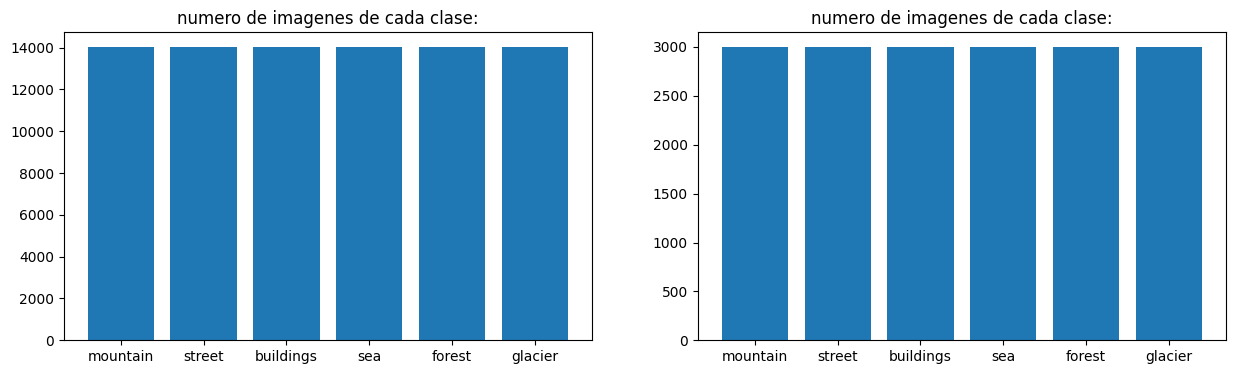

In [102]:
data = ['train', 'test']
folder = [train_folder, test_folder]
fig,axes =plt.subplots(nrows=1, ncols=2, figsize=(15,4))
axes = axes.ravel()
for i, ax in enumerate(axes):
  num_images, classes = get_num_images(folder[i]), os.listdir(folder[i])
  ax.figure
  ax.bar(classes, num_images)
  ax.set_title(f'numero de imagenes de cada clase:')
plt.tight_layout
plt.show()

### 4. Cargar y visualizar imágenes con `torchvision.datasets.ImageFolder`

Vamos a cargar un subconjunto de las imágenes de entrenamiento utilizando `torchvision.datasets.ImageFolder` para verificar que la carga y la estructura de las clases son correctas. También aplicaremos algunas transformaciones básicas.

In [103]:
import torchvision

# Definir transformaciones para las imágenes
transform = transforms.Compose([
    transforms.Resize((64, 64)), # Redimensionar todas las imágenes a un tamaño uniforme
    transforms.ToTensor(),       # Convertir la imagen a un tensor PyTorch
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # Normalizar (valores típicos para imágenes)
])

# Crear el conjunto de datos de entrenamiento usando ImageFolder
train_dataset = torchvision.datasets.ImageFolder(root=train_folder, transform=transform)

# Mostrar algunas estadísticas del dataset
print(f'Número de imágenes en el conjunto de entrenamiento: {len(train_dataset)}')
print(f'Clases encontradas: {train_dataset.classes}')
print(f'Mapeo de clases a índices: {train_dataset.class_to_idx}')

Número de imágenes en el conjunto de entrenamiento: 14034
Clases encontradas: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Mapeo de clases a índices: {'buildings': 0, 'forest': 1, 'glacier': 2, 'mountain': 3, 'sea': 4, 'street': 5}


Ahora, visualicemos algunas imágenes de ejemplo del conjunto de entrenamiento para asegurarnos de que se han cargado correctamente y sus etiquetas corresponden a las clases esperadas.

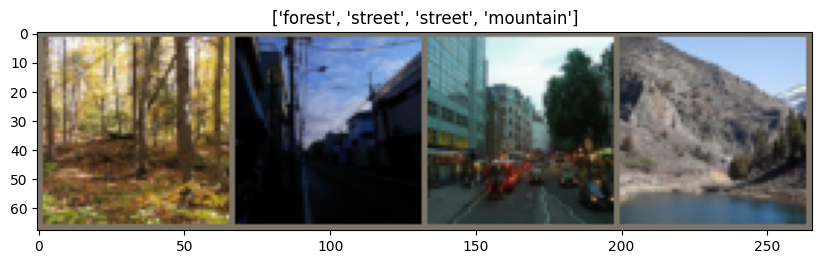

In [104]:
def imshow(inp, title=None):
    """Imshow for Tensors."""
    inp = inp.numpy().transpose((1, 2, 0)) # Convertir de tensor (C, H, W) a array numpy (H, W, C)
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean # Desnormalizar
    inp = np.clip(inp, 0, 1) # Recortar valores para asegurar que estén en [0, 1]
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)  # pause a bit so that plots are updated

# Obtener un batch de entrenamiento aleatorio para visualizar
data_loader = torch.utils.data.DataLoader(train_dataset, batch_size=4, shuffle=True)

# Obtener algunas imágenes de entrenamiento
images, labels = next(iter(data_loader))

# Crear una cuadrícula de imágenes
out = torchvision.utils.make_grid(images)

# Visualizar las imágenes
plt.figure(figsize=(10,5))
imshow(out, title=[train_dataset.classes[x] for x in labels])
plt.show()

### 5. Aumento de imágenes

In [105]:
# Mostrar la imagen original junto con la transformada
def plot_images(image, image_trans, title, title_trans):
  fig, ax = plt.subplots(1, 2, figsize=(10, 5))
  ax[0].imshow(image)
  ax[0].set_title(title)
  ax[1].imshow(image_trans)
  ax[1].set_title(title_trans)
  plt.show()

### 6. Aumento de Datos con `transforms.Compose`

Vamos a definir un conjunto más completo de transformaciones de aumento de datos utilizando `transforms.Compose`. Esto incluirá redimensionamiento, volteo horizontal aleatorio, rotación aleatoria, y finalmente, la conversión a tensor y normalización. Luego, visualizaremos algunas imágenes aumentadas para observar el efecto de estas transformaciones.

In [106]:
# Definir transformaciones de aumento de datos
augmented_transform = transforms.Compose([
    transforms.Resize((64, 64)),                  # Redimensionar
    transforms.RandomHorizontalFlip(),            # Volteo horizontal aleatorio
    transforms.ColorJitter(brightness=0.5),       # Imagen más brillante
    transforms.RandomGrayscale(p=0.2),            # Imagen en escala de grises
    transforms.RandomVerticalFlip(0.3),           # Volteo vertical aleatorio
    transforms.RandomRotation(30),                # Rotación aleatoria
    transforms.ToTensor(),                        # Convertir a tensor
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # Normalizar
])

# Crear un nuevo conjunto de datos de entrenamiento con las transformaciones aumentadas
augmented_train_dataset = torchvision.datasets.ImageFolder(root=train_folder, transform=augmented_transform)

print(f'Número de imágenes en el conjunto de entrenamiento aumentado: {len(augmented_train_dataset)}')
print(f'Clases encontradas: {augmented_train_dataset.classes}')

Número de imágenes en el conjunto de entrenamiento aumentado: 14034
Clases encontradas: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


Ahora, visualicemos algunas imágenes de este nuevo conjunto de datos aumentado para ver el efecto de las transformaciones.

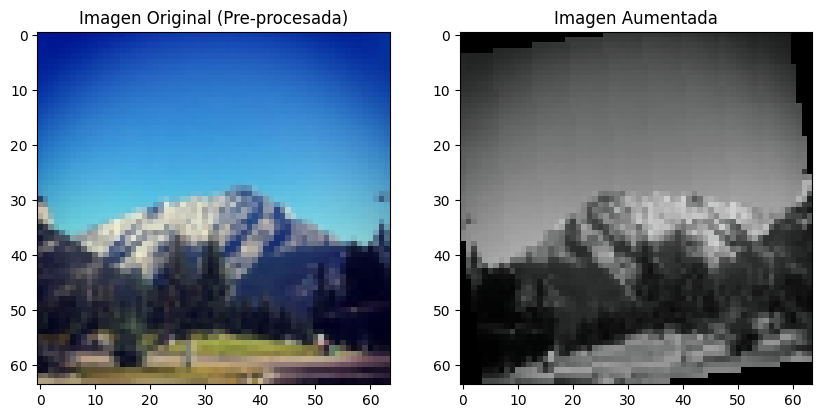

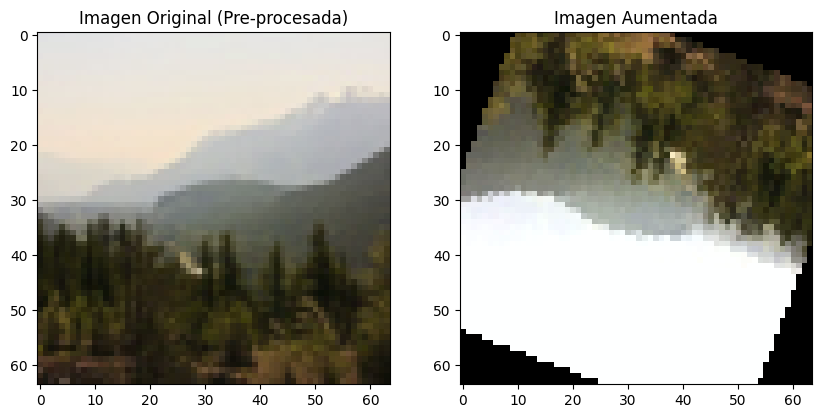

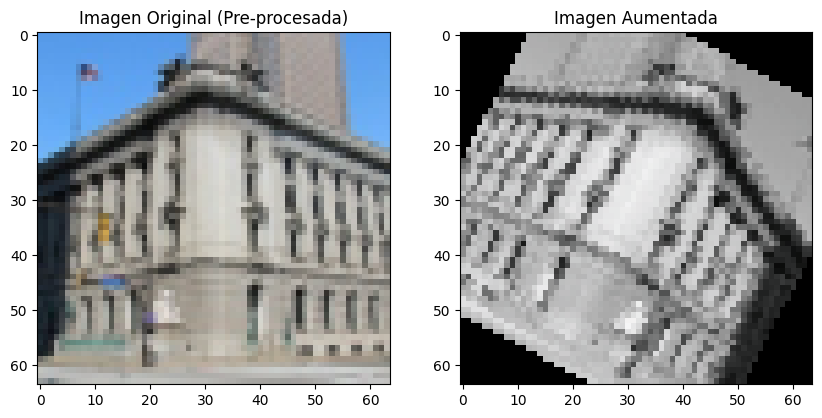

In [107]:
# Seleccionar múltiples imágenes y visualizarlas

num_comparisons = 3 # Número de pares de imágenes a mostrar

for _ in range(num_comparisons):
    # Obtener una lista de las carpetas de clases (ej. 'mountain', 'street')
    class_folders = [d for d in os.listdir(train_folder) if os.path.isdir(os.path.join(train_folder, d))]
    random_class = random.choice(class_folders)
    class_path = os.path.join(train_folder, random_class)

    # Obtener una lista de los archivos de imagen en la clase seleccionada
    image_files = [f for f in os.listdir(class_path) if f.endswith(('.jpg', '.jpeg', '.png'))]
    random_image_file = random.choice(image_files)
    image_path = os.path.join(class_path, random_image_file)

    # Cargar la imagen original como una imagen PIL
    pil_image = Image.open(image_path).convert('RGB')

    # Aplicar el transform básico (redimensionar, ToTensor, Normalizar) para la versión 'no transformada' (solo preprocesada)
    tensor_original_processed = transform(pil_image)

    # Aplicar el augmented_transform para la versión 'aumentada'
    tensor_augmented = augmented_transform(pil_image)

    # Desnormalizar y transponer los tensores a arrays numpy para plot_images
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    def denormalize_tensor_to_np_array(tensor):
        np_array = tensor.numpy().transpose((1, 2, 0))
        np_array = std * np_array + mean
        np_array = np.clip(np_array, 0, 1)
        return np_array

    image_display_original = denormalize_tensor_to_np_array(tensor_original_processed)
    image_display_augmented = denormalize_tensor_to_np_array(tensor_augmented)

    # Visualizar la imagen original (pre-procesada) y la aumentada usando plot_images
    plot_images(image_display_original, image_display_augmented, "Imagen Original (Pre-procesada)", "Imagen Aumentada")


### 5. Definir y entrenar la red convolucional

In [108]:
class ImagePredictor(nn.Module):

  # Definimos el constructor
  def __init__(self, num_classes):
    super(ImagePredictor, self).__init__()

    # Definimos las capas convolucionales
    self.network = nn.Sequential(
        # Entrada: [batch, 3, 64, 64]
        nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1), # -> [batch, 16, 64, 64]
        nn.MaxPool2d(kernel_size=2, stride=2),  # -> [batch, 16, 32, 32]
        nn.ReLU(),

        # Segunda capa convolucional
        nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1), # -> [batch, 32, 32, 32]
        nn.MaxPool2d(kernel_size=2, stride=2), # -> [batch, 32, 16, 16]
        nn.ReLU(),

        # Cambiamos dimensiones
        nn.Flatten(),  # -> [batch, 32 * 16 * 16]

        # Ajustamos in_features a 32 * 16 * 16 = 8192
        nn.Linear(in_features= 32 * 16 * 16, out_features=num_classes)
    )

  def forward(self, x):
    x = self.network(x)
    return torch.log_softmax(x, dim=1)

In [109]:
# especificar que queremos usar la GPU de google colab
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [110]:
# inicializar modelo y mandarlo a GPU
model = ImagePredictor(num_classes =len(classes)).to(device)
print(model)

ImagePredictor(
  (network): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (2): ReLU()
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): ReLU()
    (6): Flatten(start_dim=1, end_dim=-1)
    (7): Linear(in_features=8192, out_features=6, bias=True)
  )
)


Especificamos función de coste y optimizador

In [111]:
learning_rate = 0.0001

optimizer =optim.Adam(model.parameters(), lr=learning_rate)
loss_criteria = nn.CrossEntropyLoss()

  Definimos funciones para entrenamiento y validación

In [112]:
def train(model, device, train_loader, optimizer, loss_criteria):
    model.train()

    epoch_loss = 0
    elements = 0
    correct = 0

    # procesar imagenes en batches
    for i_batch, (images, labels) in enumerate(train_loader):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        output = model(images)
        batch_loss = loss_criteria(output, labels)
        batch_loss.backward()
        optimizer.step()

        epoch_loss += batch_loss.item()
        elements += labels.size(0)
        pred = output.argmax(dim=1, keepdim=True)
        correct += pred.eq(labels.view_as(pred)).sum().item()

    # calcular métrica para época entera
    loss_train = epoch_loss / len(train_loader)
    acc_train = 100.0 * correct / elements

    return loss_train, acc_train

In [113]:
def evaluate(model, device, test_loader, loss_criteria):
    model.eval()

    epoch_loss = 0
    elements = 0
    correct = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            output = model(images)
            batch_loss = loss_criteria(output, labels)

            epoch_loss += batch_loss.item()
            elements += labels.size(0)
            pred = output.argmax(dim=1, keepdim=True)
            correct += pred.eq(labels.view_as(pred)).sum().item()

    loss_test = epoch_loss / len(test_loader)
    acc_test = 100.0 * correct / elements

    return loss_test, acc_test

In [114]:
def train_evaluation(epochs, model, train_loader, test_loader, optimizer, loss_criteria, device):
    train_loss = []
    train_acc = []
    test_loss = []
    test_acc = []

    for epoch in range(epochs):
        # Entrenamiento
        loss_train, acc_train = train(model, device, train_loader, optimizer, loss_criteria)
        train_loss.append(loss_train)
        train_acc.append(acc_train)

        # Evaluación (cambiar nombre a evaluate en lugar de llamar a sí misma)
        loss_test, acc_test = evaluate(model, device, test_loader, loss_criteria)
        test_loss.append(loss_test)
        test_acc.append(acc_test)

        # Corrección del print - usar valores individuales, no listas
        print(f'Epoch: {epoch:4d} | Train_loss: {loss_train:6.4f} | Train_acc: {acc_train:5.2f}% | Test_loss: {loss_test:6.4f} | Test_acc: {acc_test:5.2f}%')

    return train_loss, train_acc, test_loss, test_acc

Ahora definiremos los `DataLoaders` para los conjuntos de entrenamiento y prueba. Usaremos el `augmented_train_dataset` para el entrenamiento y un nuevo `test_dataset` con las transformaciones básicas para la evaluación.

In [115]:
batch_size = 64

# Crear el conjunto de datos de prueba
test_dataset = torchvision.datasets.ImageFolder(root=test_folder, transform=transform)

# Crear DataLoaders para entrenamiento y prueba
train_loader = torch.utils.data.DataLoader(augmented_train_dataset, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f'Número de batches en train_loader: {len(train_loader)}')
print(f'Número de batches en test_loader: {len(test_loader)}')


Número de batches en train_loader: 220
Número de batches en test_loader: 47


Entrenamos modeo ejecutando bucle

In [116]:
epochs = 30
loss_values_train, acc_values_train, loss_values_test, acc_values_test = train_evaluation(epochs, model, train_loader, test_loader, optimizer, loss_criteria, device)

Epoch:    0 | Train_loss: 1.4661 | Train_acc: 41.96% | Test_loss: 1.1819 | Test_acc: 54.77%
Epoch:    1 | Train_loss: 1.2338 | Train_acc: 51.38% | Test_loss: 1.0821 | Test_acc: 58.77%
Epoch:    2 | Train_loss: 1.1665 | Train_acc: 54.56% | Test_loss: 1.0410 | Test_acc: 59.17%
Epoch:    3 | Train_loss: 1.1278 | Train_acc: 56.64% | Test_loss: 0.9783 | Test_acc: 63.70%
Epoch:    4 | Train_loss: 1.1013 | Train_acc: 58.05% | Test_loss: 0.9655 | Test_acc: 62.27%
Epoch:    5 | Train_loss: 1.0603 | Train_acc: 59.32% | Test_loss: 0.9315 | Test_acc: 66.33%
Epoch:    6 | Train_loss: 1.0380 | Train_acc: 60.20% | Test_loss: 0.9106 | Test_acc: 66.43%
Epoch:    7 | Train_loss: 1.0180 | Train_acc: 61.55% | Test_loss: 0.8870 | Test_acc: 67.33%
Epoch:    8 | Train_loss: 1.0046 | Train_acc: 61.61% | Test_loss: 0.8684 | Test_acc: 68.37%
Epoch:    9 | Train_loss: 0.9862 | Train_acc: 62.98% | Test_loss: 0.8670 | Test_acc: 67.50%
Epoch:   10 | Train_loss: 0.9797 | Train_acc: 63.35% | Test_loss: 0.8478 | Test_

### 6. Evaluación


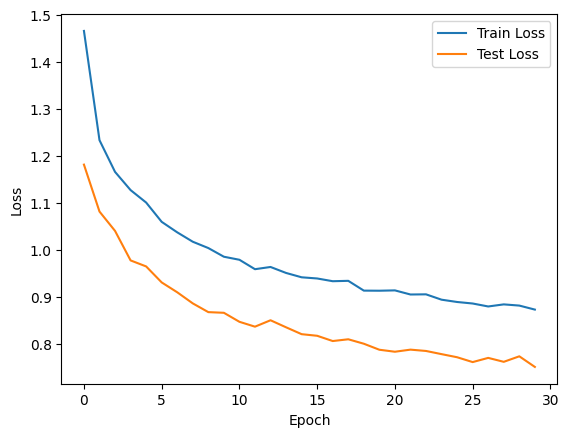

In [120]:
plt.plot(loss_values_train, label='Train Loss')
plt.plot(loss_values_test, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

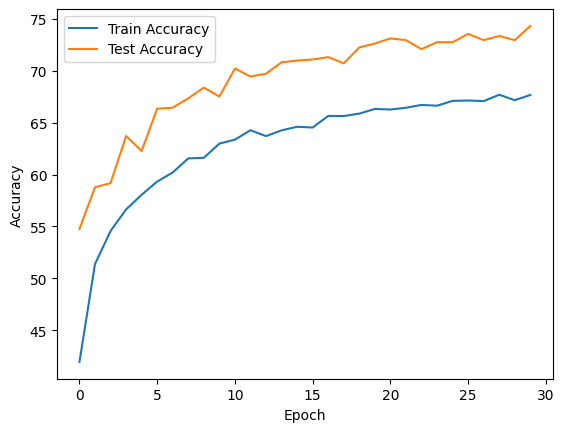

In [121]:
plt.plot(acc_values_train, label='Train Accuracy')
plt.plot(acc_values_test, label='Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

Vemos que cuanto más aumnetan las épocas, el loss es menor y el accuraccy mayor por lo que estamos en un buen indicador de que el modelo está aprendiendo bien.

Dibujo l amatriz de confusion con los datos de test para ver que bien clasifica el modelo creado.

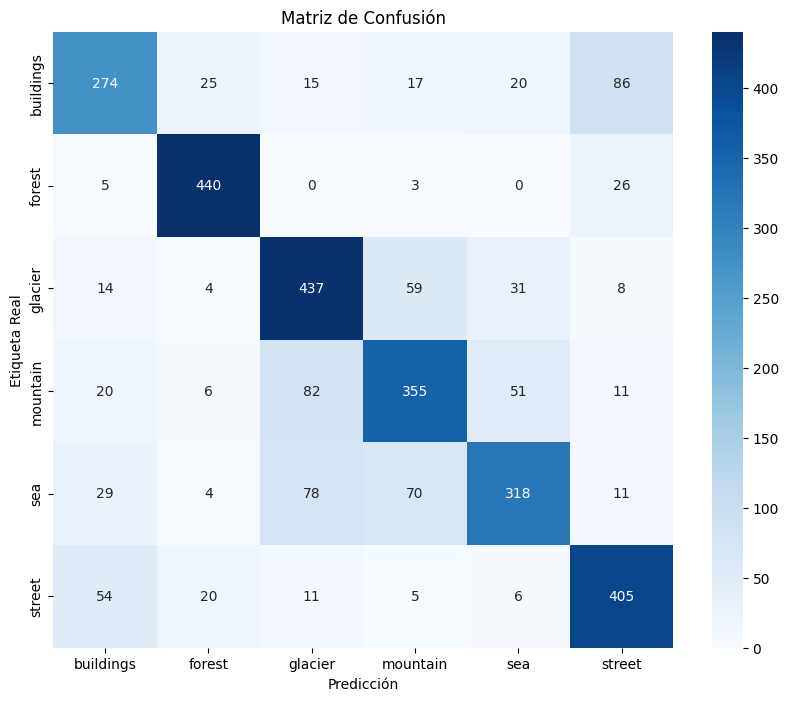

In [126]:
def plot_confusion_matrix(model, device, test_loader, classes):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            predictions = outputs.argmax(dim=1)

            all_preds.extend(predictions.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Calcular matriz de confusión
    cm = confusion_matrix(all_labels, all_preds)

    # Visualizar
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes)
    plt.title('Matriz de Confusión')
    plt.ylabel('Etiqueta Real')
    plt.xlabel('Predicción')
    plt.show()

    return cm

# Usar con la lista de clases del dataset
cm = plot_confusion_matrix(model, device, test_loader, classes=train_dataset.classes)

Vemos que tal predice con imagenes nueva sin label.

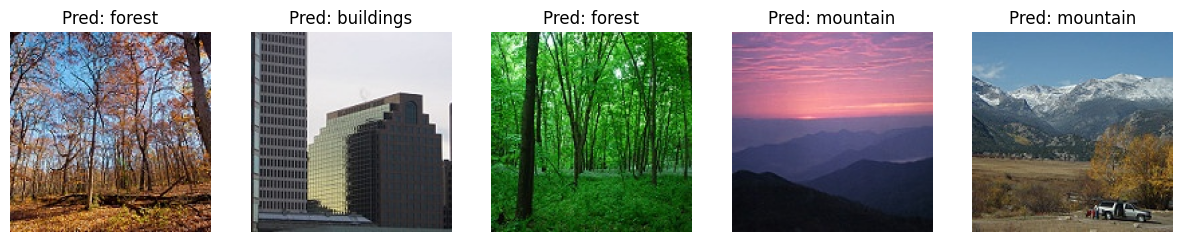

In [128]:
# 7. Predicción en imágenes nuevas (seg_pred)
model.eval()

# Obtener lista de imágenes en la carpeta de predicción
pred_images = [f for f in os.listdir(pred_folder) if f.endswith(('.jpg', '.png', '.jpeg'))]

# Seleccionar 5 imágenes aleatorias para probar
sample_images = random.sample(pred_images, 5)

plt.figure(figsize=(15, 5))

for i, img_name in enumerate(sample_images):
    img_path = os.path.join(pred_folder, img_name)
    img_pil = Image.open(img_path).convert('RGB')

    # Aplicar las mismas transformaciones que en el test_set
    input_tensor = transform(img_pil).unsqueeze(0).to(device)

    # Realizar la predicción
    with torch.no_grad():
        output = model(input_tensor)
        prob = torch.exp(output)
        pred_idx = torch.argmax(prob, dim=1).item()
        pred_class = train_dataset.classes[pred_idx]

    # Visualizar
    plt.subplot(1, 5, i+1)
    plt.imshow(img_pil)
    plt.title(f"Pred: {pred_class}")
    plt.axis('off')

plt.show()